In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Enviroment ready")

Enviroment ready


In [ ]:
oil_rate_bopd = 1200      # barrels of oil per day
gas_rate_mscfd = 850     # thousand standard cubic feet per day
pressure_psi = 3200      # reservoir pressure

# Unit conversion
psi_to_pa = 6894.76
pressure_pa = pressure_psi * psi_to_pa

pressure_pa


22063232.0

In [ ]:
def barrels_to_cubic_meters(barrels):
    return barrels * 0.158987

barrels_to_cubic_meters(1200)

190.78439999999998

In [ ]:
data = {
    "Month": pd.date_range(start="2022-01-01", periods=12, freq="ME"),
    "Oil_Rate_bopd": [1200, 1150, 1100, 1050, 980, 920, 860, 810, 760, 720, 680, 650]
}

df = pd.DataFrame(data)
df

,Month,Oil_Rate_bopd
0,2022-01-31,1200
1,2022-02-28,1150
2,2022-03-31,1100
3,2022-04-30,1050
4,2022-05-31,980
5,2022-06-30,920
6,2022-07-31,860
7,2022-08-31,810
8,2022-09-30,760
9,2022-10-31,720


In [ ]:
df["Oil_Produced_bbl"] = df["Oil_Rate_bopd"] * 30
df["Cumulative_Oil_bbl"] = df["Oil_Produced_bbl"].cumsum()
display(df)

,Month,Oil_Rate_bopd,Oil_Produced_bbl,Cumulative_Oil_bbl
0,2022-01-31,1200,36000,36000
1,2022-02-28,1150,34500,70500
2,2022-03-31,1100,33000,103500
3,2022-04-30,1050,31500,135000
4,2022-05-31,980,29400,164400
5,2022-06-30,920,27600,192000
6,2022-07-31,860,25800,217800
7,2022-08-31,810,24300,242100
8,2022-09-30,760,22800,264900
9,2022-10-31,720,21600,286500


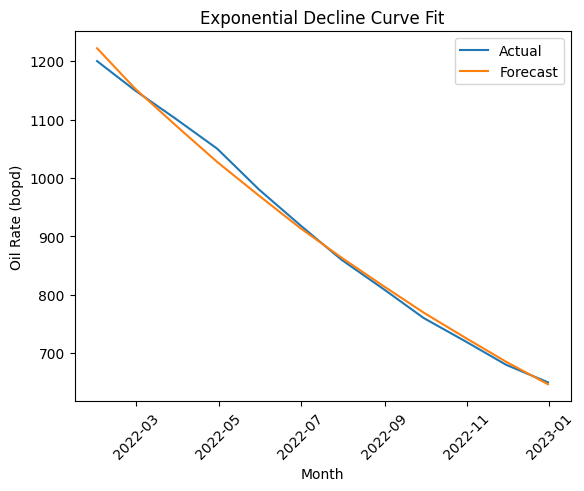

In [ ]:
q_forecast = exponential_decline(t, qi, Di)

plt.figure()
plt.plot(df["Month"], q, label="Actual")
plt.plot(df["Month"], q_forecast, label="Forecast")
plt.xlabel("Month")
plt.ylabel("Oil Rate (bopd)")
plt.title("Exponential Decline Curve Fit")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy.optimize import curve_fit

def exponential_decline(t, qi, Di):
    return qi * np.exp(-Di * t)

t = np.arange(len(df))
q = df["Oil_Rate_bopd"].values

params, _ = curve_fit(exponential_decline, t, q)
qi, Di = params

qi, Di

/tmp/ipython-input-3688991551.py:4: RuntimeWarning: overflow encountered in exp
  return qi * np.exp(-Di * t)


(np.float64(1221.9669095048578), np.float64(0.057854355814286273))

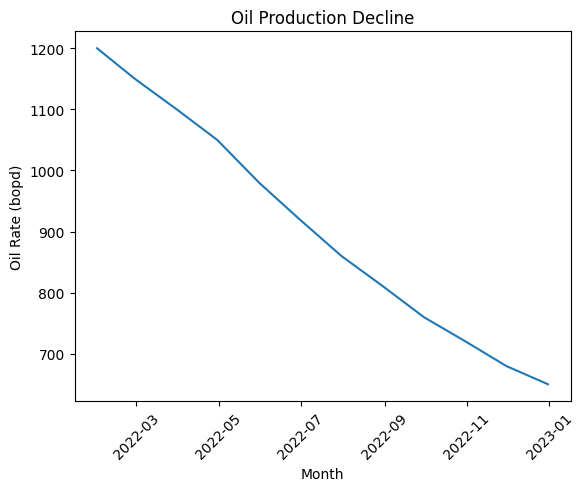

In [ ]:
plt.figure()
plt.plot(df["Month"], df["Oil_Rate_bopd"])
plt.xlabel("Month")
plt.ylabel("Oil Rate (bopd)")
plt.title("Oil Production Decline")
plt.xticks(rotation=45)
plt.show()